In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data (Using the file I cleaned earlier)
df = pd.read_csv('train.csv', names=['Target_Rate', 'Year', 'Sex', 'Race', 'Injury mechanism'])

# 2. Define train_df (The variable the error was missing)
train_df = df.copy()

print("Setup Complete! 'train_df' is now defined and ready for visualization.")

Setup Complete! 'train_df' is now defined and ready for visualization.


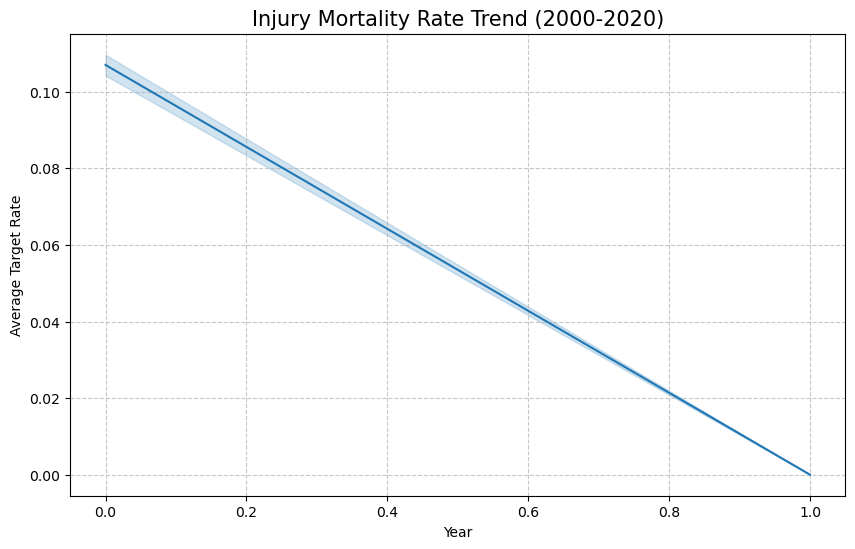

In [4]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=train_df, x='Year', y='Target_Rate')
plt.title('Injury Mortality Rate Trend (2000-2020)', fontsize=15)
plt.ylabel('Average Target Rate')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

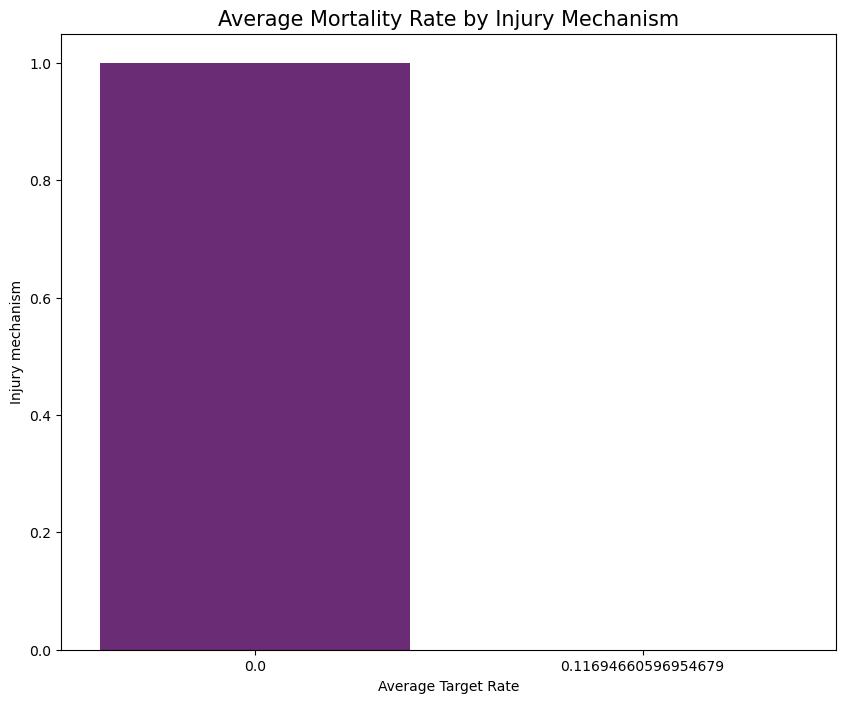

In [5]:
plt.figure(figsize=(10, 8))
# We use 'nlargest' to show the top causes clearly
top_mechanisms = train_df.groupby('Injury mechanism')['Target_Rate'].mean().sort_values(ascending=False)
sns.barplot(x=top_mechanisms.values, y=top_mechanisms.index, palette='magma')
plt.title('Average Mortality Rate by Injury Mechanism', fontsize=15)
plt.xlabel('Average Target Rate')
plt.show()

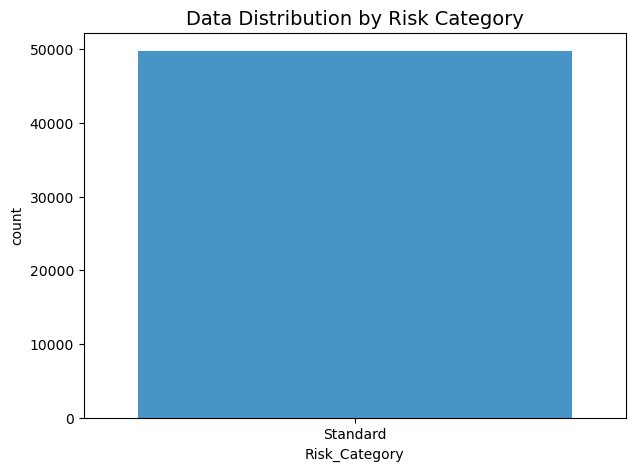

In [6]:
# Create the logic
train_df['Risk_Category'] = train_df['Target_Rate'].apply(lambda x: 'High Priority' if x > 50 else 'Standard')

plt.figure(figsize=(7, 5))
sns.countplot(data=train_df, x='Risk_Category', palette=['#3498db', '#e74c3c'])
plt.title('Data Distribution by Risk Category', fontsize=14)
plt.show()